# REGRESIÓN LOGISTICA MULTICLASE PARA CLASIFICACIÓN DE FRIJOLES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset)

# IMPORTAMOS LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DESCARGAMOS DATASET DE KAGGLE

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sansuthi/dry-bean-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.01M/1.01M [00:00<00:00, 116MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sansuthi/dry-bean-dataset/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/sansuthi/dry-bean-dataset/versions/1

Dry_Bean.csv


In [4]:
PATH_CSV = path + '/Dry_Bean.csv'

In [5]:
df = pd.read_csv(PATH_CSV)
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [6]:
df.dtypes.value_counts()

,count
float64,14
int64,2
object,1


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(68)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

# UNDERSAMPLING
## CUANDO LAS CLASES ESTAN DESBALANCEADAS ES NECESARIO BALANCEAR

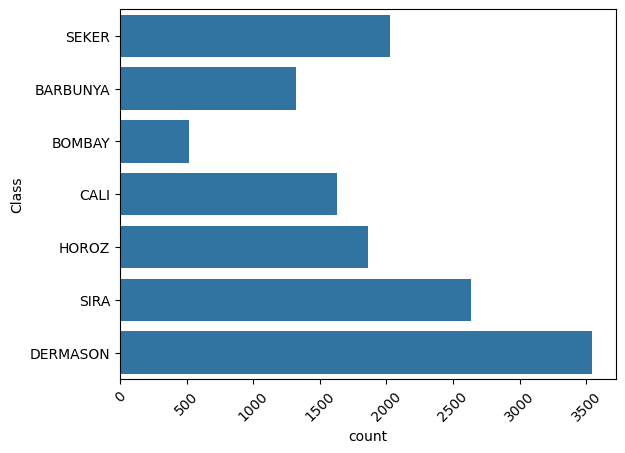

In [11]:
sns.countplot(df['Class'])
plt.xticks(rotation=45)
plt.show()

In [12]:
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(random_state=42)

In [13]:
X = df.drop('Class',axis=1)
y = df['Class']

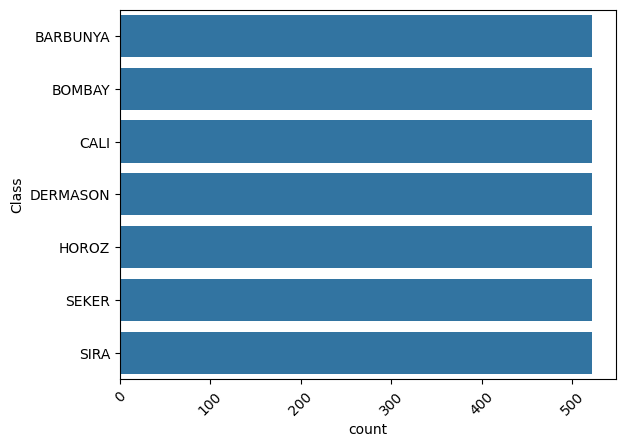

In [14]:
X_over,y_over = undersample.fit_resample(X,y)
sns.countplot(y_over)
plt.xticks(rotation=45)
plt.show()

# CODIFIACIÓN DE VARIABLE DEPENDIENTE

In [15]:
y_over.replace(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],[1,2,3,4,5,6,7],inplace=True)
list(np.unique(y_over))

/tmp/ipykernel_1948/4064676665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_over.replace(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],[1,2,3,4,5,6,7],inplace=True)


[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7)]

# CORRELACIONES

In [16]:
df_corr = X_over
df_corr['Class'] = y_over
corr_matrix = df_corr.corr()
corr_class = corr_matrix['Class']
corr_class.sort_values(ascending=False)

,Class
Class,1.000000
ShapeFactor1,0.595998
ShapeFactor2,0.493776
roundness,0.436332
Solidity,0.320507
ShapeFactor4,0.202544
ShapeFactor3,0.177881
Compactness,0.160470
Extent,-0.084210
AspectRation,-0.100902


<Axes: >

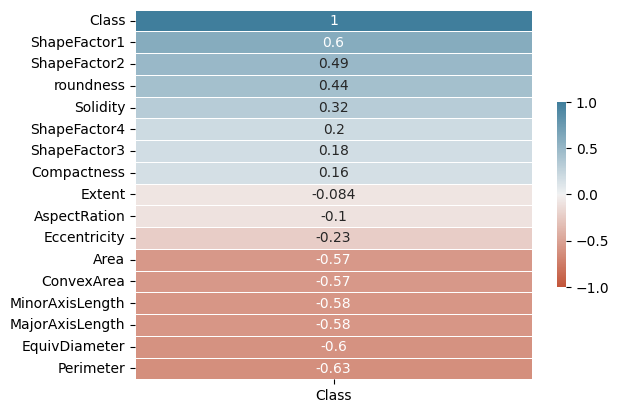

In [17]:
sns.heatmap(
    data=corr_class.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

# ENTRENAMIENTO DEL MODELO DE CLASIFICACIÓN MULTICLASE

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X_over,y_over,random_state=42,shuffle=True,test_size=0.2)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ESTRATEGIAS PARA MANEJAR PROBLEMAS DE CLASIFICACIÓN MULTICLASE
* OVER(ONE VS REST) : esta estrategia entrena un clasificador binario por cada clase.
* multinomial : rota todas las clases al mismo tiempo en un solo modelo de clasificación multiclase.

# OVER

In [21]:
from sklearn.multiclass import OneVsRestClassifier
model_ovr = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=500))
model_ovr.fit(X_train,y_train)
y_pred_ovr = model_ovr.predict(X_test)
print(f"Ovr Accuracy : {accuracy_score(y_test,y_pred_ovr)}")

Ovr Accuracy : 0.9863201094391245


## MATRIZ DE CONFUSIÓN

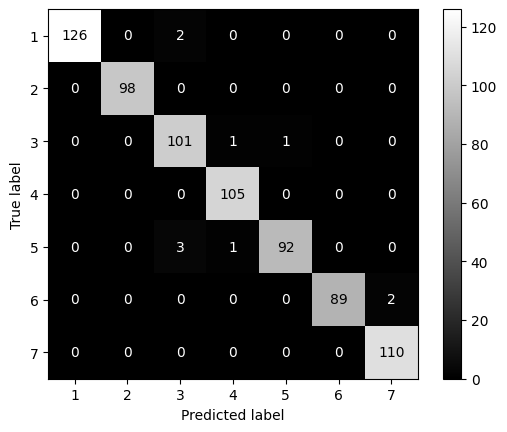

In [22]:
cm = confusion_matrix(y_test,y_pred_ovr,labels=model_ovr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_ovr.classes_)
disp.plot(cmap='gray')
plt.show()

# USANDO MULTINOMIAL

In [23]:
model_multinomial = LogisticRegression(multi_class='multinomial',solver='lbfgs',max_iter=500)
model_multinomial.fit(X_train,y_train)
y_pred_multinomial = model_multinomial.predict(X_test)
print(f"Ovr Multinomial : {accuracy_score(y_test,y_pred_multinomial)}")

Ovr Multinomial : 0.9945280437756497


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


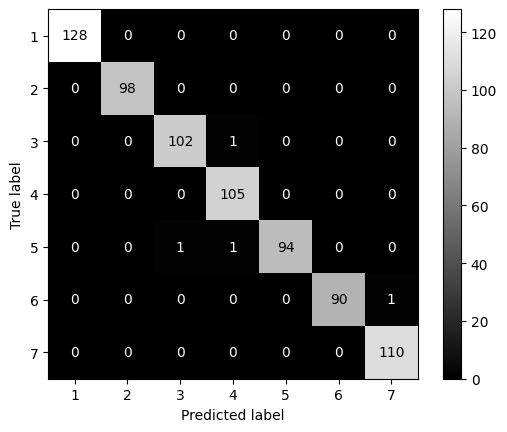

In [24]:
cm = confusion_matrix(y_test,y_pred_multinomial,labels=model_multinomial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_multinomial.classes_)
disp.plot(cmap='gray')
plt.show()